# Imports

In [17]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import re

# Load Dataset

In [18]:
# Load dataset
df = pd.read_csv("spam.csv", encoding="latin-1")[["v1","v2"]]
df.columns = ["label","text"]

# Encode labels
le = LabelEncoder()
df["label"] = le.fit_transform(df["label"])

# Text Cleaning

In [19]:
# Text cleaning
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

df["text"] = df["text"].apply(clean_text)

# Tokenization

In [20]:
# Tokenization
vocab = {}
def build_vocab(texts):
    idx = 1
    for text in texts:
        for word in text.split():
            if word not in vocab:
                vocab[word] = idx
                idx += 1

build_vocab(df["text"])

# Encode text
def encode(text):
    return [vocab[w] for w in text.split() if w in vocab]

df["encoded"] = df["text"].apply(encode)

# Padding
MAX_LEN = 40
def pad(seq):
    if len(seq) < MAX_LEN:
        seq += [0]*(MAX_LEN-len(seq))
    return seq[:MAX_LEN]

df["padded"] = df["encoded"].apply(pad)

X = np.array(df["padded"].tolist())
y = df["label"].values

# Train split
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

#  Dataset

Epoch 1/5 | Train Loss 0.4133 | Test Loss 0.4073
Epoch 2/5 | Train Loss 0.3968 | Test Loss 0.3995
Epoch 3/5 | Train Loss 0.3939 | Test Loss 0.3938
Epoch 4/5 | Train Loss 0.3915 | Test Loss 0.3982
Epoch 5/5 | Train Loss 0.3933 | Test Loss 0.3941


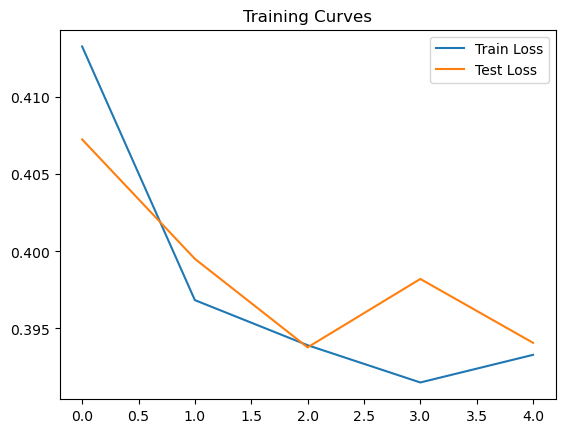

In [21]:
# Dataset
class SpamDataset(Dataset):
    def __init__(self,X,y):
        self.X=torch.tensor(X,dtype=torch.long)
        self.y=torch.tensor(y,dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self,idx):
        return self.X[idx],self.y[idx]

train_loader=DataLoader(SpamDataset(X_train,y_train),batch_size=64,shuffle=True)
test_loader=DataLoader(SpamDataset(X_test,y_test),batch_size=64)

# Model
class LSTMModel(nn.Module):
    def __init__(self,vocab_size):
        super().__init__()
        self.embedding=nn.Embedding(vocab_size+1,64)
        self.lstm=nn.LSTM(64,128,batch_first=True)
        self.fc=nn.Linear(128,1)
        self.sigmoid=nn.Sigmoid()

    def forward(self,x):
        x=self.embedding(x)
        _,(h,_)=self.lstm(x)
        x=self.fc(h[-1])
        return self.sigmoid(x)

device="cuda" if torch.cuda.is_available() else "cpu"

model=LSTMModel(len(vocab)).to(device)

criterion=nn.BCELoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)

# Training
EPOCHS=5
train_loss_hist=[]
test_loss_hist=[]

for epoch in range(EPOCHS):

    model.train()
    train_loss=0

    for Xb,yb in train_loader:
        Xb,yb=Xb.to(device),yb.to(device)

        optimizer.zero_grad()

        preds=model(Xb).squeeze()
        loss=criterion(preds,yb)

        loss.backward()
        optimizer.step()

        train_loss+=loss.item()

    train_loss/=len(train_loader)

    model.eval()
    test_loss=0

    with torch.no_grad():
        for Xb,yb in test_loader:
            Xb,yb=Xb.to(device),yb.to(device)

            preds=model(Xb).squeeze()
            loss=criterion(preds,yb)

            test_loss+=loss.item()

    test_loss/=len(test_loader)

    train_loss_hist.append(train_loss)
    test_loss_hist.append(test_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss {train_loss:.4f} | Test Loss {test_loss:.4f}")

# Save model
torch.save(model.state_dict(),"best_spam_lstm.pth")

# Plot curves
plt.plot(train_loss_hist,label="Train Loss")
plt.plot(test_loss_hist,label="Test Loss")
plt.legend()
plt.title("Training Curves")
plt.savefig("spam_training_curves.png")
plt.show()